# Policy gradient

- Finite Diﬀerence Policy Gradient
- Monte-Carlo Policy Gradient
- Actor-Critic Policy Gradient

## Policy-Based Reinforcement Learning

### From Value Functions to Policy

Previously, we approximated value functions with parameters $\theta$:

$$V_\theta(s) \approx V^\pi(s)$$
$$Q_\theta(s, a) \approx Q^\pi(s, a)$$

The policy was then **derived indirectly** from these value functions — e.g. via $\varepsilon$-greedy: take the action with highest $Q$, with occasional random exploration.

### Direct Policy Parametrisation

Now we skip the value function and **parametrise the policy directly**:

$$\pi_\theta(s, a) = \mathbb{P}[a \mid s, \theta]$$

This reads: *"given state $s$ and parameters $\theta$, what is the probability of taking action $a$?"*

Instead of learning *"how good is this state/action?"*, we learn *"what action should I take in this state?"* directly.

> The policy outputs a **probability distribution** over actions — stochastic by nature, unlike $\varepsilon$-greedy which is deterministic with added noise.

## Scope

We stay in the **model-free** setting — no knowledge of environment dynamics ($P$, $R$). The agent learns purely from sampled experience.

## Value-Based and Policy-Based RL

Three families of RL algorithms, differing in what they learn:

| | Value Function | Policy |
|---|---|---|
| **Value-Based** | ✅ Learnt | Implicit (e.g. $\varepsilon$-greedy) |
| **Policy-Based** | ❌ None | ✅ Learnt |
| **Actor-Critic** | ✅ Learnt | ✅ Learnt |

### Value-Based
Learns $Q(s,a)$ or $V(s)$, then derives a policy implicitly — no explicit policy is stored.

### Policy-Based
Directly learns $\pi_\theta(s,a)$. No value function at all. Examples: REINFORCE.

### Actor-Critic
Learns both. The **critic** estimates the value function (to reduce variance), the **actor** updates the policy directly. Best of both worlds.

## Advantages of Policy-Based RL

### Advantages

- **Better convergence properties** — optimising the policy directly tends to be more stable than value-based methods, which can oscillate or diverge.
- **Effective in high-dimensional or continuous action spaces** — value-based methods need $\arg\max_a Q(s,a)$, which is intractable when actions are continuous. Policy-based methods output actions directly.
- **Can learn stochastic policies** — sometimes the optimal policy is genuinely random (e.g. in partially observable or adversarial settings). $\varepsilon$-greedy is a hack; $\pi_\theta$ can learn the right distribution naturally.

### Disadvantages

- **Converges to a local optimum** — gradient ascent on the policy objective is not convex; no guarantee of finding the global best.
- **High variance, sample-inefficient** — policy evaluation requires rolling out full episodes, and the gradient estimates are noisy. This is the main motivation for Actor-Critic methods.

## Example: Rock-Paper-Scissors

Classic two-player zero-sum game: scissors beats paper, rock beats scissors, paper beats rock.

### Why deterministic policies fail

In the *iterated* version (many rounds against the same opponent), any deterministic policy is exploitable:
if you always play rock, your opponent learns this and always plays paper.

### The optimal policy is stochastic

Playing each action with probability $\frac{1}{3}$ is the **Nash equilibrium** — no opponent can gain an edge
regardless of their strategy, because your moves are unpredictable.

> This is a key motivation for policy-based RL: value-based methods (e.g. $\varepsilon$-greedy) cannot
> represent a truly uniform random policy. Direct policy parametrisation can.

## Example: Aliased Gridworld (1)

A gridworld where the agent cannot distinguish the two grey states (partial observability).
The money ($) is the goal; skulls are traps.

<img src="./imgs/image-106.png" width="400px"/>



### Feature representation

We work with features $\phi(s, a)$ instead of raw states.

Example feature:

$$\phi(s, a) = \mathbf{1}(\text{wall to N}, a = \text{move E})$$

The grey states are the two cells that look identical to the agent — same features $\phi(s,a)$  (e.g. wall to the north in both cases).

The problem: one grey state requires going left to reach the money, the other requires going right. But since the agent can't tell them apart, it must apply the same policy to both.

### Two approaches

**Value-based** — learn an approximate action-value function:

$$Q_\theta(s, a) = f(\phi(s, a), \theta)$$

The policy is then implicit: take $\arg\max_a Q_\theta(s, a)$.

**Policy-based** — directly learn a policy:

$$\pi_\theta(s, a) = g(\phi(s, a), \theta)$$

Outputs a probability distribution over actions given the features.

> Because the two grey states look identical, a deterministic policy must do the
> same thing in both — which may be suboptimal. A stochastic policy can hedge,
> which is the advantage shown in the next slide.

### Example: Aliased Gridworld (2) — Why Deterministic Policies Fail

<img src="./imgs/image-107.png" width="400px" />

#### The aliasing trap

A deterministic policy must do the **same thing in both grey states** (they look identical).
So it must pick one of:

- always move **W** in both grey states, or
- always move **E** in both grey states

Either way, one grey state will send the agent in the wrong direction — away from the money
and potentially into a skull. It can get **stuck in a loop** and never reach the goal.

#### Value-based RL makes this worse

Greedy or $\varepsilon$-greedy policies are **near-deterministic** — they almost always pick
$\arg\max_a Q(s,a)$. Since both grey states map to the same $Q$ values (identical features),
the agent commits to one direction and traverses the corridor back and forth for a long time
without ever reaching the money.

#### The fix

A **stochastic policy** (policy-based RL) can assign probability 0.5 to W and 0.5 to E in the
grey states — guaranteed to eventually reach the money from either grey state, just by chance.


### Example: Aliased Gridworld (3) — Optimal Stochastic Policy

<img src="./imgs/image-108.png" width="400px" />



#### Solution: randomise in aliased states

Since both grey states have walls to the N and S, the optimal stochastic policy simply
plays 50/50:

$$\pi_\theta(\text{wall to N and S, move E}) = 0.5$$
$$\pi_\theta(\text{wall to N and S, move W}) = 0.5$$

From either grey state, the agent will eventually pick the correct direction by chance
and reach the money in a few steps — with high probability.

#### Key takeaway

Policy-based RL **can learn this stochastic policy directly** via gradient ascent on $\theta$.
Value-based RL cannot — greedy action selection always collapses to a deterministic choice,
which is provably suboptimal here.

> Partial observability (aliasing) is a

## Policy Objective Functions

Goal: given policy $\pi_\theta(s, a)$ with parameters $\theta$, find best $\theta$. 

But how do we measure the quality of a policy $\pi_\theta$?

**Episodic environments — start value:**

$$J_1(\theta) = V^{\pi_\theta}(s_1) = \mathbb{E}_{\pi_\theta}[v_1]$$

The objective is simply the value of the fixed start state $s_1$. Maximising $J_1$ means finding the policy that yields the highest expected return from the beginning of an episode.

**Continuing environments — average value:**

$$J_{avV}(\theta) = \sum_s d^{\pi_\theta}(s) V^{\pi_\theta}(s)$$

There is no start state, so we weight each state's value by how often the policy visits it (the stationary distribution $d^{\pi_\theta}(s)$).

**Continuing environments — average reward per time-step:**

$$J_{avR}(\theta) = \sum_s d^{\pi_\theta}(s) \sum_a \pi_\theta(s, a) \mathcal{R}_s^a$$

Equivalent alternative: the expected immediate reward per step, again weighted by $d^{\pi_\theta}(s)$.

**Key concept — $d^{\pi_\theta}(s)$** is the **stationary distribution** of the Markov chain induced by $\pi_\theta$: the long-run fraction of time the agent spends in state $s$.

> All three objectives are equivalent up to a constant in the continuing case; in practice $J_{avR}$ is most common for continuing tasks.

### Stationary Distribution $d^{\pi_\theta}(s)$

#### What it is

When you follow policy $\pi_\theta$ forever, the agent visits states with certain long-run
frequencies. These frequencies converge to a fixed distribution — the **stationary distribution**:

$$d^{\pi_\theta}(s) = \lim_{t \to \infty} P(S_t = s \mid \pi_\theta)$$

No matter where you start, after enough steps, the probability of being in state $s$
stabilizes to $d^{\pi_\theta}(s)$.

#### Intuition

Think of it as the fraction of time the agent spends in each state at steady state.
If $d^{\pi_\theta}(s) = 0.3$, the agent is in state $s$ roughly 30% of the time in the long run.

#### Why it matters for $J_{avV}$ and $J_{avR}$

These objectives measure **average** performance — so states visited more often should count
more. $d^{\pi_\theta}(s)$ is the natural weighting: it reflects how relevant each state
actually is under the current policy.

#### Key property

$d^{\pi_\theta}(s)$ **depends on $\theta$** — change the policy, change which states are
visited frequently. This makes gradient computation non-trivial, but the
**Policy Gradient Theorem** handles it elegantly.

## Policy Optimisation

Policy-based RL is an **optimisation problem**: find $\theta$ that maximises $J(\theta)$.

### Gradient-free approaches

Simple but less efficient — they explore the parameter space without computing gradients (when gradient is not available):

- **Hill climbing** — perturb $\theta$, keep change if $J$ improves
- **Simplex / Nelder-Mead** — geometry-based search over $\theta$ space
- **Genetic algorithms** — evolve a population of $\theta$ candidates

### Gradient-based approaches

More efficient — they follow the direction of steepest ascent $\nabla_\theta J(\theta)$:

- **Gradient descent** — direct step along $\nabla_\theta J(\theta)$
- **Conjugate gradient** — smarter steps that avoid redundant directions
- **Quasi-Newton** — approximates curvature (second-order) for faster convergence

### Focus

We focus on **gradient descent** and methods that exploit the **sequential structure**
of RL — i.e., the fact that rewards are collected over a trajectory of $(s, a, r)$ steps,
which allows efficient gradient estimation without knowing the full model.

## Policy Gradient

Let $J(\theta)$ be any policy objective function. Policy gradient algorithms find a
**local maximum** of $J(\theta)$ by repeatedly stepping $\theta$ in the direction that
increases $J$ the most:

$$\Delta\theta = \alpha \nabla_\theta J(\theta)$$

where $\alpha$ is the **step size** (learning rate) controlling how large each update is.

### The gradient vector

$\nabla_\theta J(\theta)$ is the **policy gradient** — a vector of partial derivatives,
one per parameter:

$$\nabla_\theta J(\theta) = \begin{pmatrix} \frac{\partial J(\theta)}{\partial \theta_1} \\ \vdots \\ \frac{\partial J(\theta)}{\partial \theta_n} \end{pmatrix}$$

Each component $\frac{\partial J(\theta)}{\partial \theta_i}$ answers: *"if I increase
$\theta_i$ slightly, how much does $J$ improve?"*

The full vector points in the direction of **steepest ascent** in parameter space —
so following it moves the policy toward higher expected return.



## Computing Gradients By Finite Differences

A simple numerical approach to estimate $\nabla_\theta J(\theta)$ **without analytic
differentiation**.

### Idea

For each parameter dimension $k \in [1, n]$, estimate the partial derivative by
slightly perturbing $\theta$ in that direction:

$$\frac{\partial J(\theta)}{\partial \theta_k} \approx \frac{J(\theta + \epsilon u_k) - J(\theta)}{\epsilon}$$

where $u_k$ is the unit vector in dimension $k$ (i.e. perturb only $\theta_k$ by
$\epsilon$, leave all others unchanged).

This is just the **definition of a derivative**, evaluated numerically.

### Process

1. Run policy with current $\theta$ → get $J(\theta)$
2. For each of the $n$ parameters, perturb it by $\epsilon$, run policy → get $J(\theta + \epsilon u_k)$
3. Compute the difference → one component of the gradient
4. Repeat for all $n$ dimensions → full gradient vector

This requires **$n + 1$ policy evaluations** per gradient step.

### Pros and cons

| | |
|---|---|
| ✅ Simple to implement | ❌ $n$ evaluations per step — expensive for large $\theta$ |
| ✅ Works for any policy, even non-differentiable ones | ❌ Noisy — each evaluation is a stochastic rollout |
| ✅ No need to know policy internals | ❌ Inefficient compared to analytic gradient methods |

### When to use it

Useful as a **sanity check** (gradient checking) or for low-dimensional problems **with no available gradient/differentiable policy**.

Other gradient free methods are also available

For deep neural network policies with millions of parameters, it is completely impractical — analytic methods like REINFORCE are needed instead.



Ex: when training physical robots, when policy is a decision tree or a black box simulator

# Monte-Carlo policy gradient


## Likehood ratio

### Score Function

To compute the policy gradient analytically, we assume $\pi_\theta(s, a)$ is
differentiable wherever it is non-zero, so $\nabla_\theta \pi_\theta(s, a)$ exists.

The core objective is to maximise expected return:

$$J(\theta) = \mathbb{E}_{\pi_\theta}\left[\sum_t r_t\right]$$

To do gradient ascent on $J(\theta)$, you need $\nabla_\theta J(\theta)$. 

**The problem**: the expectation itself depends on $\theta$ (the policy which uses $\theta$ determines which $(s,a)$ pairs are visited), so you can't just differentiate the reward directly.

you don't have a closed-form expression for the reward as a function of $\theta$

The expected return under trajectory distribution is:

$$J(\theta) = \int_\tau r(\tau) \, p_\theta(\tau) \, d\tau$$

Remember: 
- actions and states are continuous so $p_\theta(\tau)$ is a continuous distribution.
-  d is the stationary distribution, probability of being in a state if you play infinitely.

The reward $r(\tau)$ depends on the **trajectory** (states, actions, environment dynamics) — not on $\theta$ directly. $\theta$ only affects $p_\theta(\tau)$, the **probability of that trajectory**.

τ is a trajectory — a full sequence of states, actions, and rewards from start to finish:
$\tau = (s_0, a_0, r_0, s_1, a_1, r_1, \dots, s_T, a_T, r_T)$

Its probability under policy $\pi_\theta$ is:

$$p_\theta(\tau) = p(s_0) \prod_t \pi_\theta(a_t | s_t) \, p(s_{t+1} | s_t, a_t)$$

where $p(s_0)$ is the initial state distribution and $p(s_{t+1}|s_t, a_t)$ is the environment transition dynamics.



So the dependency is:

$$\theta \rightarrow p_\theta(\tau) \rightarrow \text{which trajectories get sampled} \rightarrow \text{expected reward}$$

Two concrete problems:

1. **The environment is a black box.** You can sample rewards, but you have no analytical expression $r(\theta)$ to differentiate.
2. **The state distribution depends on $\theta$.** Future states depend on which actions were taken, which depends on $\pi_\theta$. This makes the full dependency chain intractable to differentiate directly.




#### The likelihood ratio trick

We exploit a simple calculus identity — multiply and divide by $\pi_\theta(s, a)$:

$$\nabla_\theta \pi_\theta(s, a) = \pi_\theta(s, a) \frac{\nabla_\theta \pi_\theta(s, a)}{\pi_\theta(s, a)} = \pi_\theta(s, a) \nabla_\theta \log \pi_\theta(s, a)$$

This uses the chain rule: $\nabla \log f = \frac{\nabla f}{f}$, so $\nabla f = f \cdot \nabla \log f$.

The log-trick sidesteps this by moving the gradient **inside the expectation**, acting only on $\log \pi_\theta$ — something you **do** have an analytical form for.

Start with:

$$\nabla_\theta J(\theta) = \nabla_\theta \int r(\tau) \, p_\theta(\tau) \, d\tau$$

You want to move $\nabla_\theta$ inside the integral, but $p_\theta(\tau)$ depends on $\theta$, so you can't just differentiate $r(\tau)$ alone.

Substitute it in:

$$\nabla_\theta \int r(\tau) \, p_\theta(\tau) \, d\tau = \int r(\tau) \, p_\theta(\tau) \, \nabla_\theta \log p_\theta(\tau) \, d\tau$$

Now $p_\theta(\tau)$ is back inside as a **density**, so this is just an expectation:

$$= \mathbb{E}_{p_\theta(\tau)}\left[r(\tau) \, \nabla_\theta \log p_\theta(\tau)\right]$$

**The key insight:** instead of differentiating through the distribution (hard), you differentiate the **log-probability** (easy), and estimate the whole thing by sampling.

#### The score function

$$\nabla_\theta \log \pi_\theta(s, a)$$

This is called the **score function**. It measures how sensitive the log-probability
of action $a$ in state $s$ is to changes in $\theta$.

#### Why this matters

The rewrite turns a gradient **of a probability** into an **expectation under that
same probability**:

$$\nabla_\theta \mathbb{E}[\cdot] = \mathbb{E}\left[ \nabla_\theta \log \pi_\theta(s,a) \cdot (\cdot) \right]$$

This means we can **sample trajectories** under $\pi_\theta$ and estimate the gradient
from rollouts — without ever differentiating through the unknown environment dynamics.

#### Why the Log-Derivative Trick Converts a Gradient into an Expectation

##### Start with the objective

$$J(\theta) = \mathbb{E}_{\pi_\theta}[R] = \sum_s d^{\pi_\theta}(s) \sum_a \pi_\theta(s,a) R(s,a)$$

Taking the gradient:

$$\nabla_\theta J(\theta) = \sum_s d^{\pi_\theta}(s) \sum_a \nabla_\theta \pi_\theta(s,a) \cdot R(s,a)$$

This is **not an expectation** — we are summing $\nabla_\theta \pi_\theta$, not $\pi_\theta$.
We cannot sample from $\nabla_\theta \pi_\theta$ since it is not a probability distribution.

##### Apply the identity

$$\nabla_\theta \pi_\theta(s,a) = \pi_\theta(s,a) \cdot \nabla_\theta \log \pi_\theta(s,a)$$

Substitute:

$$\nabla_\theta J(\theta) = \sum_s d^{\pi_\theta}(s) \sum_a \pi_\theta(s,a) \cdot \nabla_\theta \log \pi_\theta(s,a) \cdot R(s,a)$$

Now the sum is weighted by $d^{\pi_\theta}(s) \cdot \pi_\theta(s,a)$ — which **is** a
valid probability distribution over $(s, a)$ pairs. So we can write:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s,a) \cdot R(s,a) \right]$$

##### Intuition

The trick works because we **reintroduce** $\pi_\theta$ into the sum by dividing and
multiplying by it. The gradient $\nabla_\theta \pi_\theta$ alone has no probabilistic
meaning. But $\pi_\theta \cdot \nabla_\theta \log \pi_\theta$ does — it is
$\pi_\theta$ times a quantity we can evaluate, so the whole expression becomes
an expectation we can **estimate by sampling rollouts**.

## Softmax Policy

A concrete, differentiable policy used as a standard example for policy gradient methods.

### Definition

Actions are weighted by a **linear combination of features** $\phi(s,a)^\top \theta$,
where $\phi(s,a)$ is a feature vector describing the state-action pair. The policy is:

$$\pi_\theta(s, a) \propto e^{\phi(s,a)^\top \theta}$$

This is just a softmax over all actions — higher feature score → higher probability.
The full normalised form is:

$$\pi_\theta(s, a) = \frac{e^{\phi(s,a)^\top \theta}}{\sum_{a'} e^{\phi(s,a')^\top \theta}}$$

### Score function for softmax

$$\nabla_\theta \log \pi_\theta(s, a) = \phi(s, a) - \mathbb{E}_{\pi_\theta}[\phi(s, \cdot)]$$

This says: the score function is the feature of the chosen action **minus the average
feature across all actions** (weighted by $\pi_\theta$).

### Intuition

- $\phi(s, a)$ — features of the action actually taken
- $\mathbb{E}_{\pi_\theta}[\phi(s, \cdot)]$ — expected features under current policy (a baseline)

The gradient is **positive** when the taken action has higher-than-average features,
pushing $\theta$ to make that action more likely. It is zero when the action is
perfectly average — no update needed.

This is a clean example of the score function having an intuitive
**"how different is this action from average"** interpretation.

## Gaussian Policy

In continuous action spaces, a Gaussian policy is natural.

The mean is a linear combination of state features:

$$\mu(s) = \phi(s)^\top \theta$$

where $\phi(s)$ is the feature vector of state $s$ and $\theta$ are the learnable parameters.

The variance $\sigma^2$ may be fixed (a hyperparameter) or also parametrised.

The policy samples actions from a Gaussian:

$$a \sim \mathcal{N}(\mu(s), \sigma^2)$$

**Score function** (gradient of the log-policy w.r.t. $\theta$):

$$\nabla_\theta \log \pi_\theta(s, a) = \frac{(a - \mu(s))\phi(s)}{\sigma^2}$$

**Intuition:** the score measures how far the chosen action $a$ was from the mean $\mu(s)$, scaled by the feature vector. If $a > \mu(s)$, the gradient pushes $\theta$ to increase the mean (and vice versa). The $\sigma^2$ denominator normalises by spread — a tighter distribution produces larger gradients for the same deviation.

## Poliy gradient Theorem


### One-step MDP


A **one-step MDP** (aka bandit) is the simplest case: the agent starts in a state, takes one action, gets a reward, and the episode ends.

- Start state sampled from a distribution: $s \sim d(s)$
- Episode terminates after one step with reward $r = \mathcal{R}_{s,a}$

---

#### Objective Function

The goal is to maximize expected reward under policy $\pi_\theta$:

$$J(\theta) = \mathbb{E}_{\pi_\theta}[r]$$

Expanding the expectation explicitly (summing over all states and actions):

$$J(\theta) = \sum_{s \in \mathcal{S}} d(s) \sum_{a \in \mathcal{A}} \pi_\theta(s, a) \mathcal{R}_{s,a}$$

Each term weights the reward $\mathcal{R}_{s,a}$ by how likely we are to be in state $s$ (given by $d(s)$) and to choose action $a$ (given by $\pi_\theta(s,a)$).

---

#### Policy Gradient

To improve the policy, we differentiate $J(\theta)$ with respect to $\theta$.

Using the **log-derivative trick**: $\nabla_\theta \pi_\theta = \pi_\theta \nabla_\theta \log \pi_\theta$

$$\nabla_\theta J(\theta) = \sum_{s \in \mathcal{S}} d(s) \sum_{a \in \mathcal{A}} \pi_\theta(s, a) \nabla_\theta \log \pi_\theta(s, a) \mathcal{R}_{s,a}$$


This is exactly the definition of an expectation $\mathbb{E}[X] = \sum_x p(x) X$, where:

- $p(s, a) = d(s) \cdot \pi_\theta(s, a)$ is the joint probability of visiting state $s$ and choosing action $a$
- $X = \nabla_\theta \log \pi_\theta(s, a) \cdot \mathcal{R}_{s,a}$ is the random variable being averaged

So the double sum is literally:

$$\sum_{s,a} \underbrace{d(s)\, \pi_\theta(s,a)}_{\text{probability of } (s,a)} \cdot \underbrace{\nabla_\theta \log \pi_\theta(s,a)\, \mathcal{R}_{s,a}}_{\text{value of the random variable}}$$


$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) \cdot r \right]$$

**Key insight:** the gradient is an expectation we can **estimate by sampling** — run the policy, collect $(s, a, r)$ tuples, and average $\nabla_\theta \log \pi_\theta(s,a) \cdot r$. No model of the environment needed.

### Policy Gradient Theorem

The one-step result generalises to **multi-step MDPs**. The only change: replace
the immediate reward $r$ with the long-term action-value $Q^{\pi}(s, a)$.

The theorem holds for any of the three standard objectives:
- $J_1$ — expected return from a fixed start state
- $J_{avR}$ — average reward per time-step
- $\frac{1}{1-\gamma} J_{avV}$ — average value (discounted)

---

#### Theorem

For any differentiable policy $\pi_\theta(s, a)$:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) \; Q^{\pi_\theta}(s, a) \right]$$

---

#### Intuition

- $\nabla_\theta \log \pi_\theta(s, a)$ — direction in parameter space that makes action $a$ more likely in state $s$
- $Q^{\pi_\theta}(s, a)$ — how good that action actually is (expected cumulative reward)

The gradient **increases the probability of actions proportionally to how good they are**.
Good actions ($Q$ high) get a strong push; bad actions ($Q$ low) get pushed down.

This is powerful because we never need to differentiate through the environment dynamics —
they are absorbed into $Q^{\pi_\theta}(s,a)$, which can be estimated from samples.

### Monte-Carlo Policy Gradient (REINFORCE)

REINFORCE applies the policy gradient theorem using **full episode returns**
as an unbiased estimate of $Q^{\pi_\theta}(s_t, a_t)$.

#### Key idea

Instead of knowing $Q^{\pi_\theta}(s_t, a_t)$ exactly, use the actual return:

$$v_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$$

This is **unbiased** (correct on average) but **high variance** (noisy episode to episode).

---

#### Parameter Update

$$\Delta\theta_t = \alpha \nabla_\theta \log \pi_\theta(s_t, a_t) \, v_t$$

- $\alpha$ — learning rate
- $\nabla_\theta \log \pi_\theta(s_t, a_t)$ — direction that makes the taken action more likely
- $v_t$ — scales the update: good outcomes reinforce the action, bad outcomes suppress it

---

#### Algorithm
```
Initialise θ arbitrarily
for each episode {s₁, a₁, r₂, ..., s_{T-1}, a_{T-1}, r_T} ~ π_θ do
    for t = 1 to T-1 do
        θ ← θ + α ∇_θ log π_θ(s_t, a_t) v_t
    end for
end for
return θ
```

1. **Sample a full episode** using the current policy
2. **For each timestep**, compute the return $v_t$ from that point forward
3. **Update $\theta$** to make high-return actions more probable

---

#### Why Monte-Carlo?

The return $v_t$ is computed from the **complete episode** (no bootstrapping).
This makes it unbiased but slow to converge — you must wait until the episode
ends before updating.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

# Policy network: state -> action probabilities
class Policy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


def compute_returns(rewards, gamma=0.99):
    """Compute discounted return v_t for each timestep."""
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns, dtype=torch.float32)
    # Normalize to reduce variance
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def reinforce(n_episodes=2000, gamma=0.99, lr=1e-2):
    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]  # 4
    action_dim = env.action_space.n              # 2

    policy = Policy(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    for episode in range(n_episodes):
        state, _ = env.reset()
        log_probs, rewards = [], []

        # --- Sample full episode ---
        done = False
        while not done:
            state_t = torch.tensor(state, dtype=torch.float32)
            probs = policy(state_t)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))   # log π_θ(s,a)
            state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            done = terminated or truncated

        # --- Compute returns v_t ---
        returns = compute_returns(rewards, gamma)

        # --- Policy gradient update ---
        # Loss = -E[log π_θ(s,a) * v_t]  (negative because we do gradient ascent)
        loss = -torch.stack(log_probs) * returns
        loss = loss.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}, total reward: {sum(rewards):.1f}")

    env.close()
    return policy


policy = reinforce()

Episode 100, total reward: 500.0
Episode 200, total reward: 216.0
Episode 300, total reward: 123.0
Episode 400, total reward: 117.0
Episode 500, total reward: 237.0
Episode 600, total reward: 233.0
Episode 700, total reward: 173.0
Episode 800, total reward: 500.0
Episode 900, total reward: 500.0
Episode 1000, total reward: 12.0
Episode 1100, total reward: 500.0
Episode 1200, total reward: 500.0
Episode 1300, total reward: 500.0
Episode 1400, total reward: 500.0
Episode 1500, total reward: 500.0
Episode 1600, total reward: 500.0
Episode 1700, total reward: 350.0
Episode 1800, total reward: 500.0
Episode 1900, total reward: 500.0
Episode 2000, total reward: 500.0


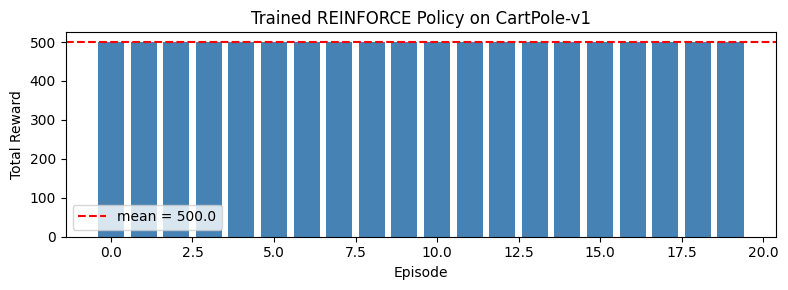

Mean reward over 20 episodes: 500.0 ± 0.0
Max: 500, Min: 500


In [3]:
import matplotlib.pyplot as plt

def evaluate_policy(policy, n_episodes=20):
    """Run the trained policy and collect episode rewards."""
    env = gym.make("CartPole-v1")
    episode_rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            with torch.no_grad():
                probs = policy(torch.tensor(state, dtype=torch.float32))
            action = probs.argmax().item()  # greedy action
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        episode_rewards.append(total_reward)
    env.close()
    return episode_rewards

rewards = evaluate_policy(policy, n_episodes=20)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(rewards)), rewards, color="steelblue")
ax.axhline(y=np.mean(rewards), color="red", linestyle="--", label=f"mean = {np.mean(rewards):.1f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.set_title("Trained REINFORCE Policy on CartPole-v1")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean reward over {len(rewards)} episodes: {np.mean(rewards):.1f} ± {np.std(rewards):.1f}")
print(f"Max: {max(rewards):.0f}, Min: {min(rewards):.0f}")

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Record one episode as RGB frames
env = gym.make("CartPole-v1", render_mode="rgb_array")
state, _ = env.reset()
frames = [env.render()]
done = False
while not done:
    with torch.no_grad():
        probs = policy(torch.tensor(state, dtype=torch.float32))
    action = probs.argmax().item()
    state, _, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    done = terminated or truncated
env.close()

# Animate the frames
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(i):
    img.set_data(frames[i])
    ax.set_title(f"Step {i}/{len(frames)-1}")
    return [img]

anim = FuncAnimation(fig, update, frames=len(frames), interval=33, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())

/Users/jkunz/Projects/cop_rl/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# additions

### Why Computing $\nabla_\theta J(\theta)$ is Hard

#### Key challenge

Computing $\nabla_\theta J(\theta)$ is non-trivial in RL because $J(\theta)$ depends on
the entire trajectory distribution, which itself depends on $\theta$. This is what the
**Policy Gradient Theorem** solves.

#### The dependency chain

$J(\theta)$ is an expectation over trajectories $\tau = (s_0, a_0, r_0, s_1, a_1, \ldots)$:

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_t r_t \right] = \sum_\tau P(\tau \mid \theta) \cdot R(\tau)$$

To improve $\theta$, we need $\nabla_\theta J(\theta)$. The problem: the **expectation
itself depends on $\theta$** through $P(\tau \mid \theta)$, so we can't just
differentiate the reward — we must also differentiate through the sampling distribution.

#### Why the environment makes it worse

The trajectory probability factorises as:

$$P(\tau \mid \theta) = \prod_t \pi_\theta(a_t \mid s_t) \cdot P(s_{t+1} \mid s_t, a_t)$$

The transition $P(s_{t+1} \mid s_t, a_t)$ is the **environment dynamics** —
unknown and not differentiable w.r.t. $\theta$.

#### The log-derivative trick (REINFORCE)

The Policy Gradient Theorem sidesteps this using the identity
$\nabla \log f = \frac{\nabla f}{f}$:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(a \mid s) \cdot Q^{\pi_\theta}(s, a) \right]$$

Key insight: the unknown environment dynamics **cancel out** — only
$\nabla_\theta \log \pi_\theta(a \mid s)$ remains, which we can compute directly.
We simply **sample trajectories** and estimate the gradient from experience.